In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import kagglehub

import warnings
warnings.filterwarnings('ignore')

In [34]:
path = kagglehub.dataset_download('santoshd3/bank-customers')

df = pd.read_csv(path + '/Churn Modeling.csv')

df_copy = df.copy()

In [35]:
df.shape

(10000, 14)

In [36]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4448,4449,15708162,Thomson,565,Germany,Female,40,1,89994.71,2,0,1,121084.27,0
6216,6217,15726634,Wei,479,France,Male,47,1,0.00,1,1,0,95270.83,0
4564,4565,15669204,Grant,650,Germany,Male,23,4,93911.30,2,1,0,69055.45,0
3113,3114,15779529,Grant,620,France,Male,32,7,0.00,2,1,1,34665.79,0
3008,3009,15665416,Ferri,779,France,Male,62,10,119096.55,1,0,1,116977.89,0
1027,1028,15769948,Palerma,737,Germany,Male,35,0,133377.80,1,0,1,64050.19,0
2186,2187,15762169,Bergman,556,Germany,Male,37,9,145018.64,2,1,0,90928.02,1
7374,7375,15696287,Converse,682,Germany,Female,38,1,116520.28,1,1,1,49833.50,1
8207,8208,15635125,Findlay,566,Spain,Male,63,2,120787.18,2,1,1,52198.84,0
8751,8752,15635531,Boag,575,Spain,Female,30,8,0.00,2,1,0,185341.63,0


In [37]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [39]:
df.isnull().sum().sum()

np.int64(0)

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [42]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df_copy = df_copy.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

KeyboardInterrupt: 

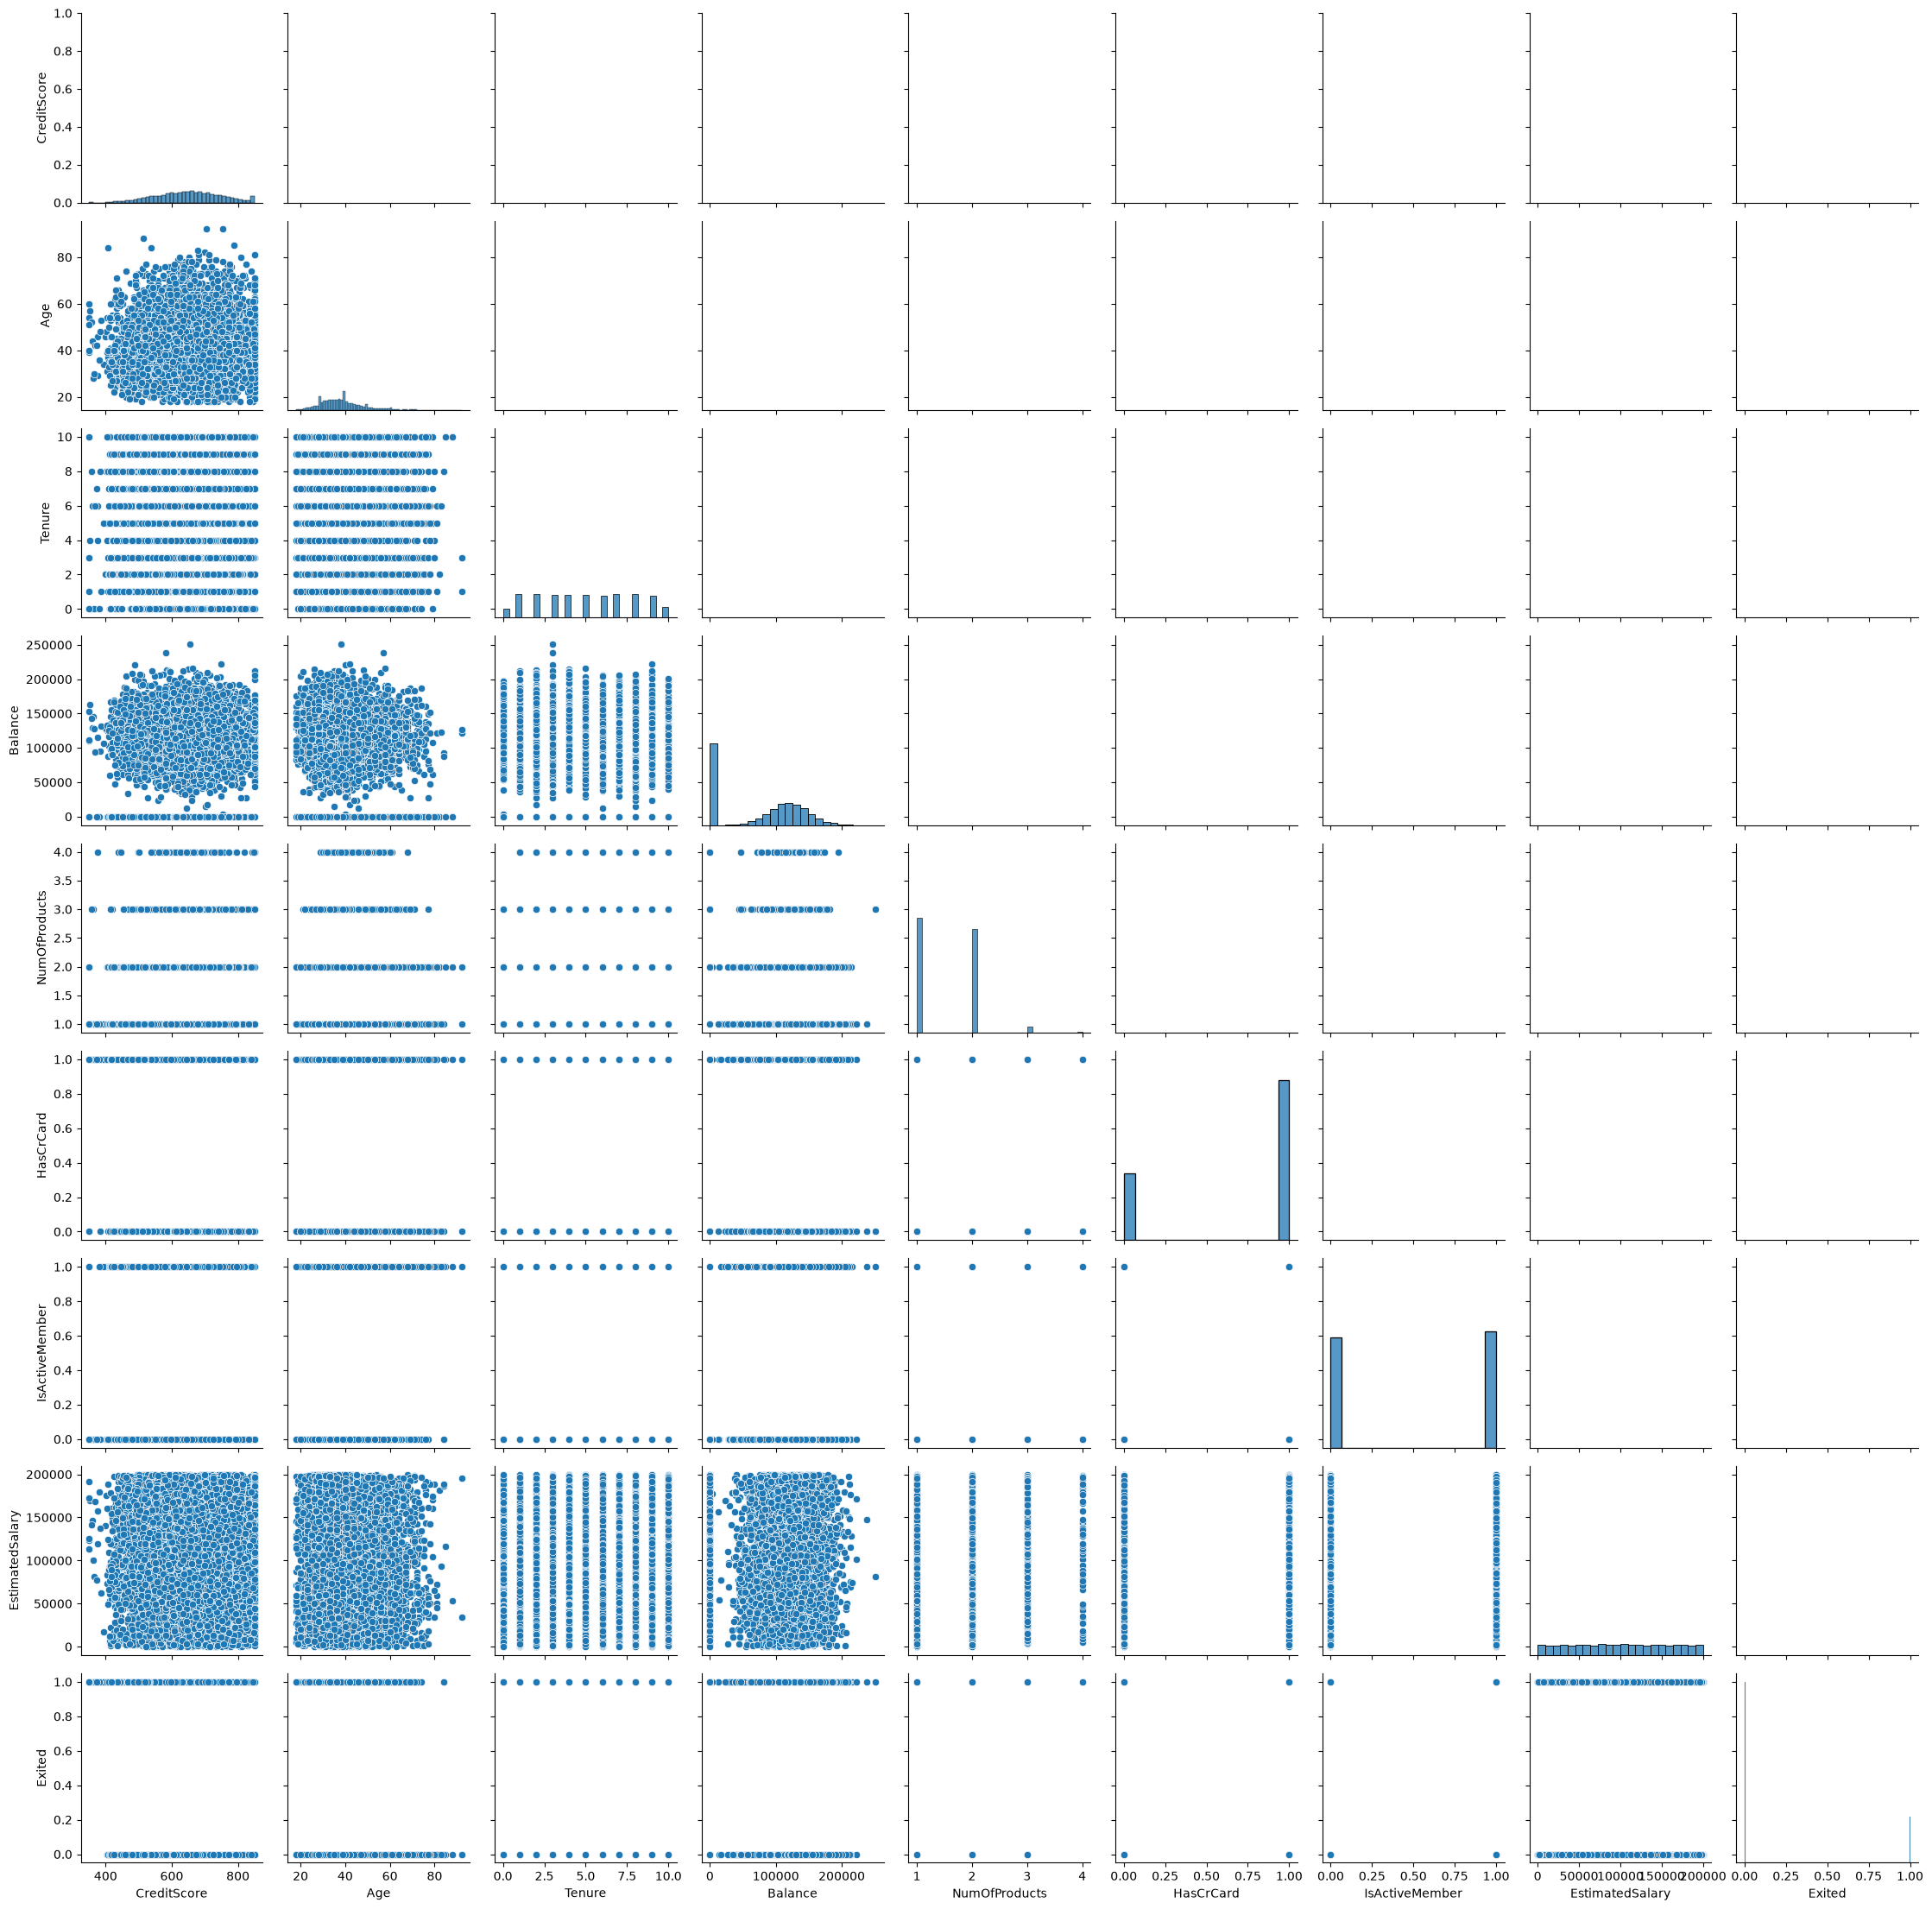

In [43]:
sns.pairplot(df) 

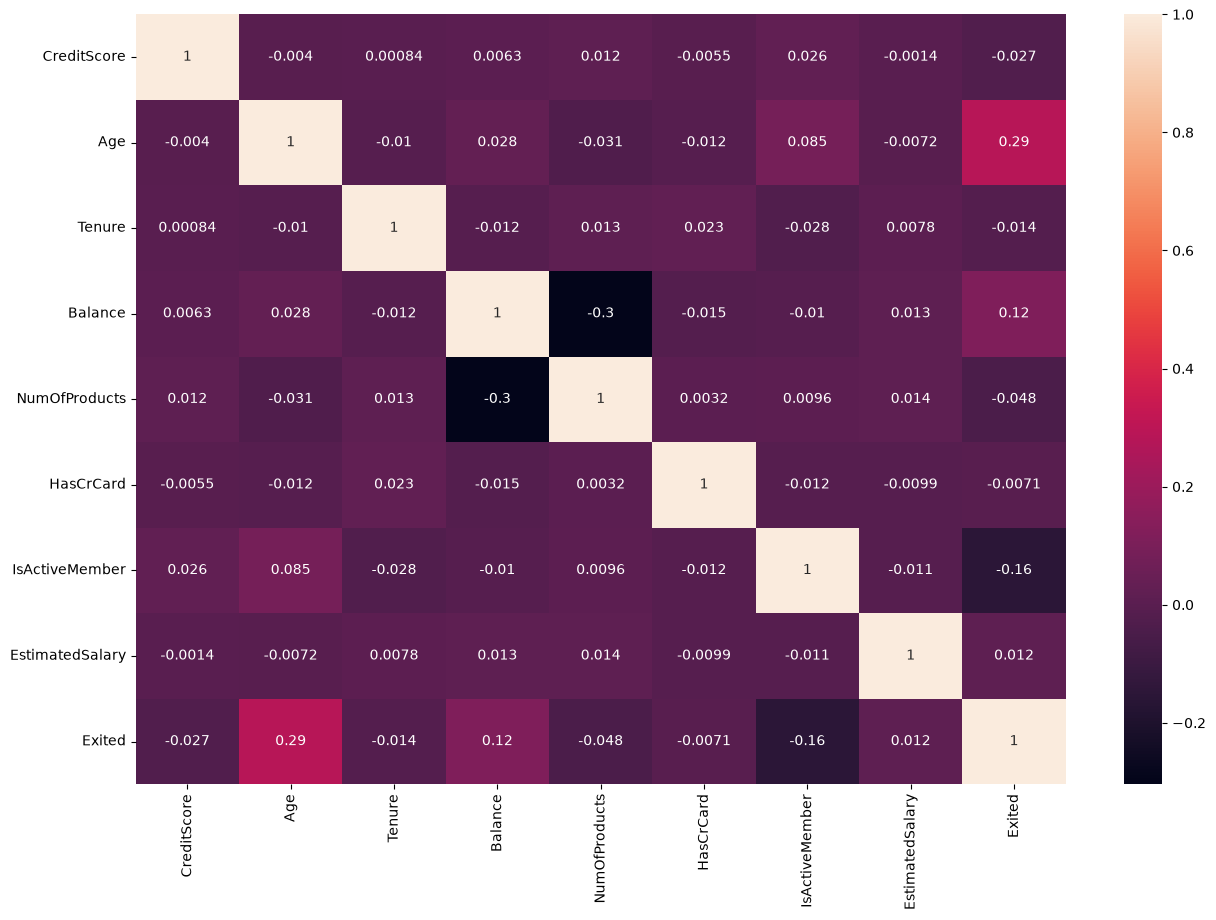

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes('number').corr(),annot=True)
plt.show()

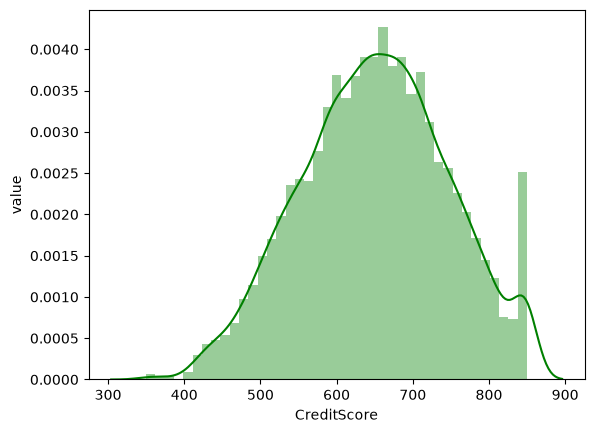

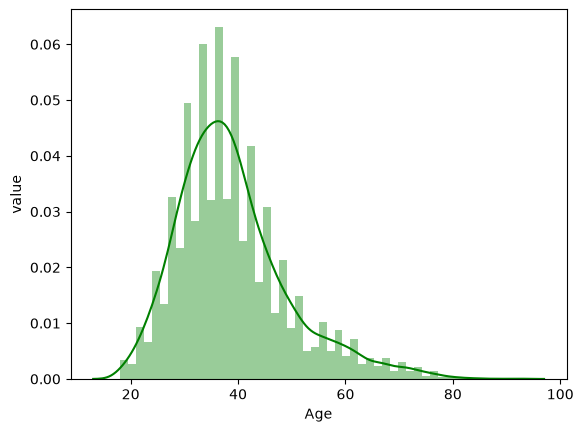

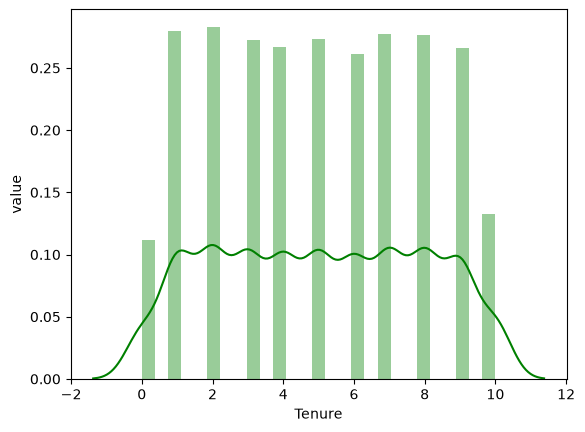

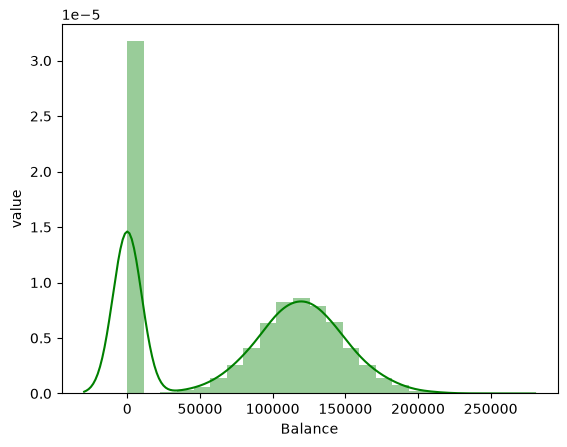

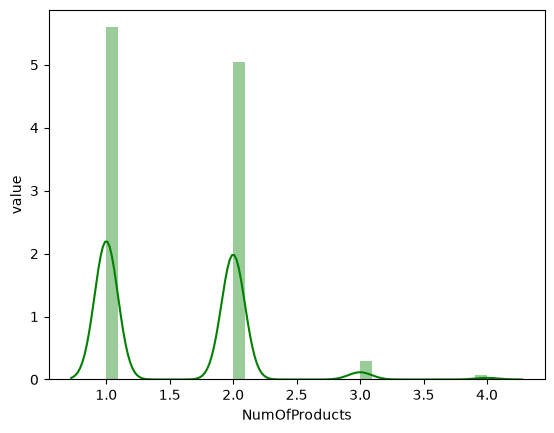

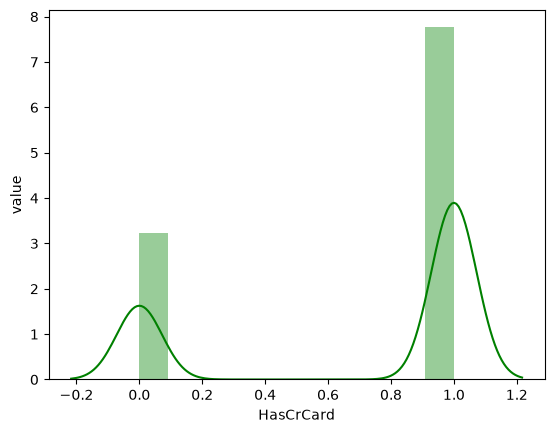

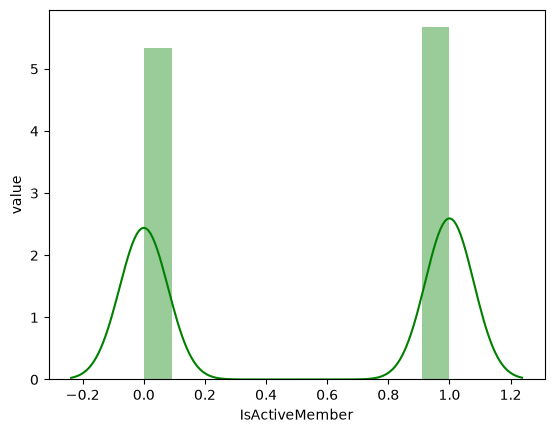

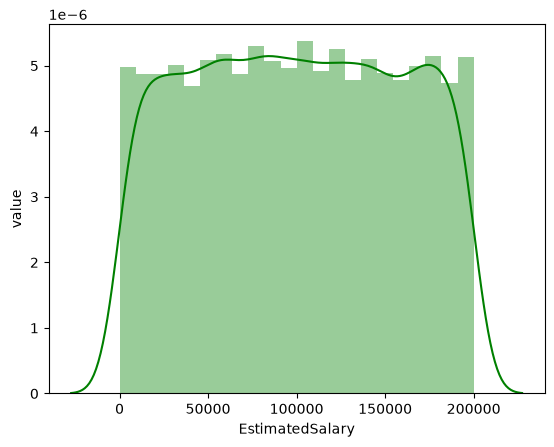

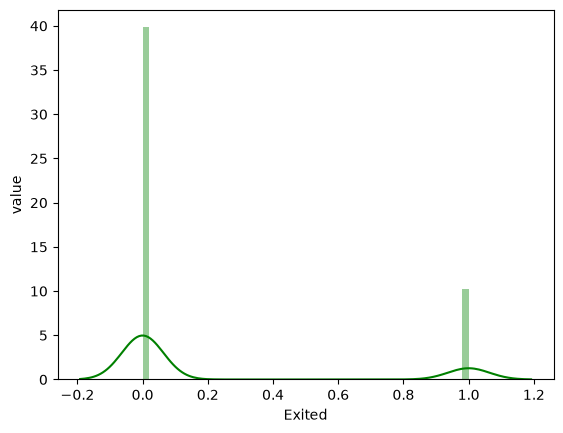

In [ ]:
for i in df.select_dtypes('number').columns:
    sns.distplot(df[i],color='green')
    plt.xlabel(i)
    plt.ylabel('value')
    plt.show()

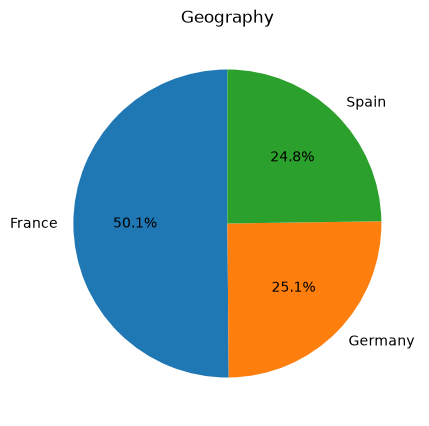

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

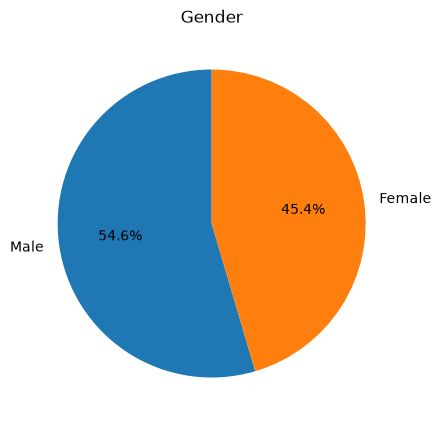

Gender
Male      5457
Female    4543
Name: count, dtype: int64

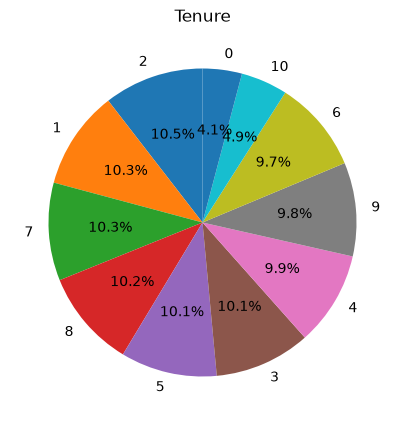

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

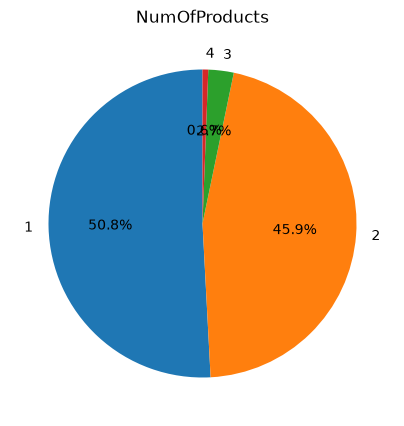

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

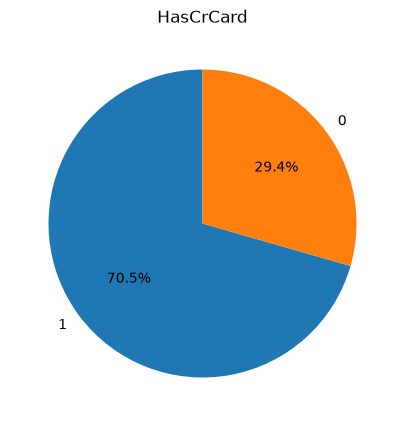

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

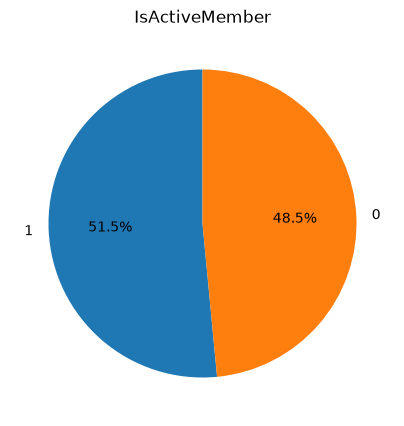

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

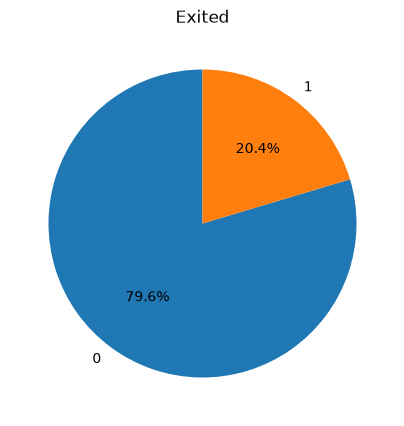

Exited
0    7963
1    2037
Name: count, dtype: int64

In [ ]:
for c in ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']:
    plt.figure(figsize=(5,5))
    df[c].value_counts().plot(kind='pie', autopct='%.1f%%', startangle=90)
    plt.ylabel('') 
    plt.title(c)
    plt.show()
    display(df[c].value_counts())

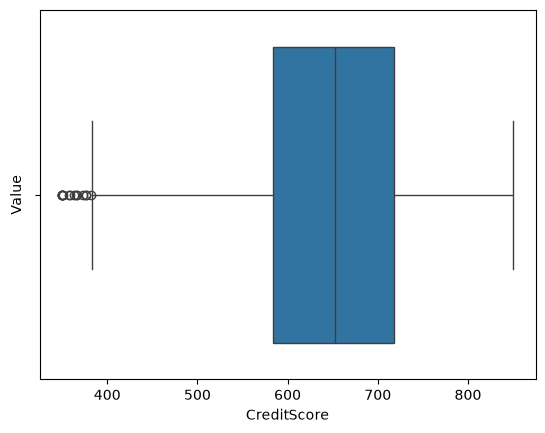

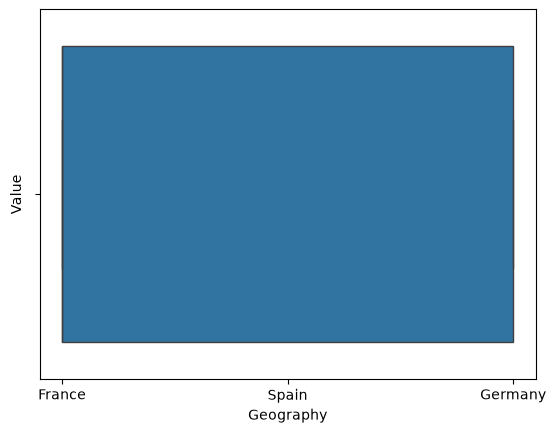

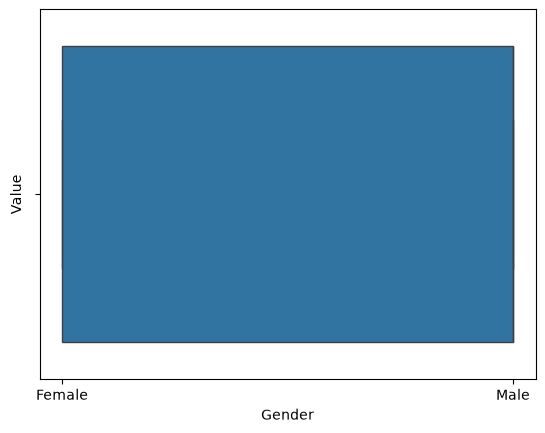

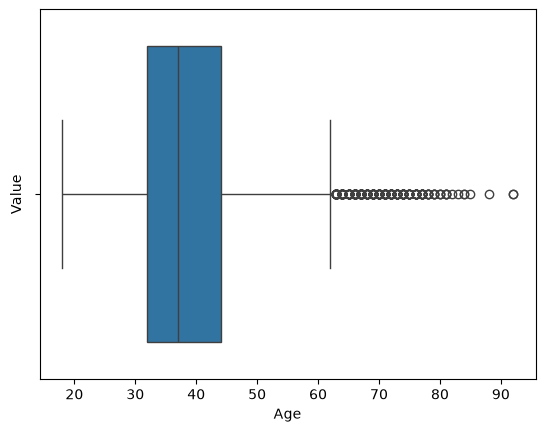

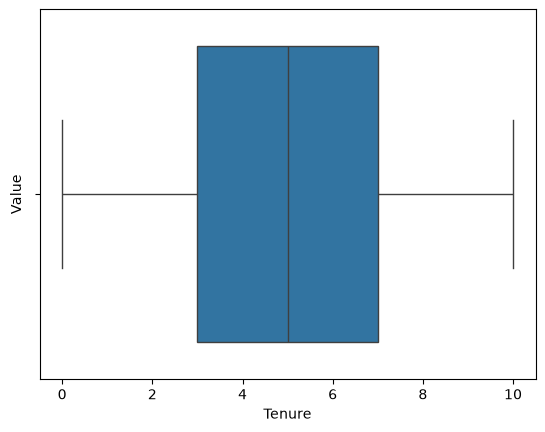

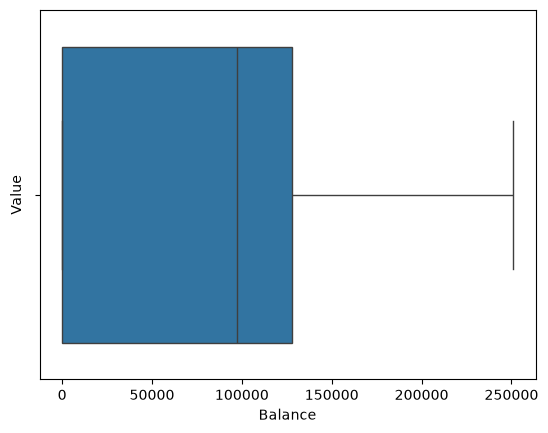

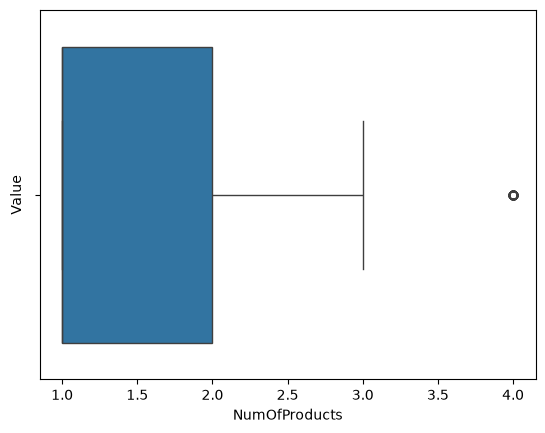

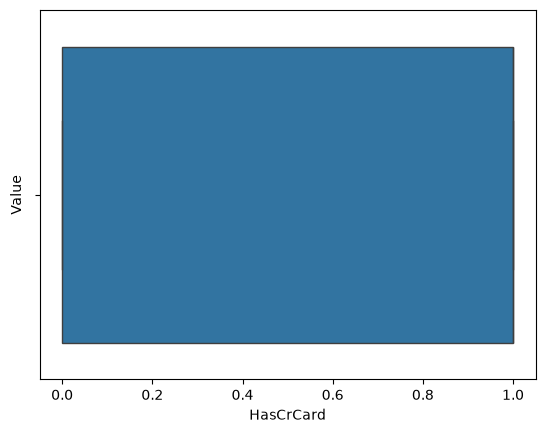

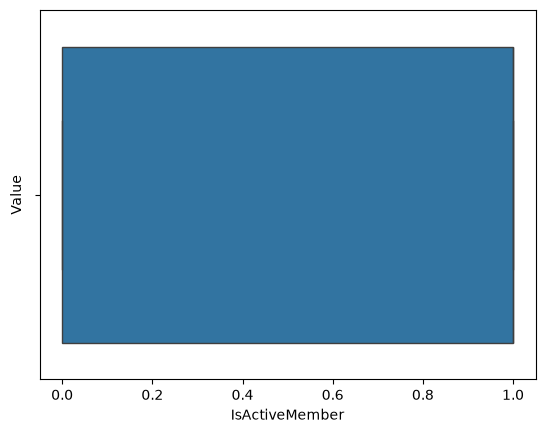

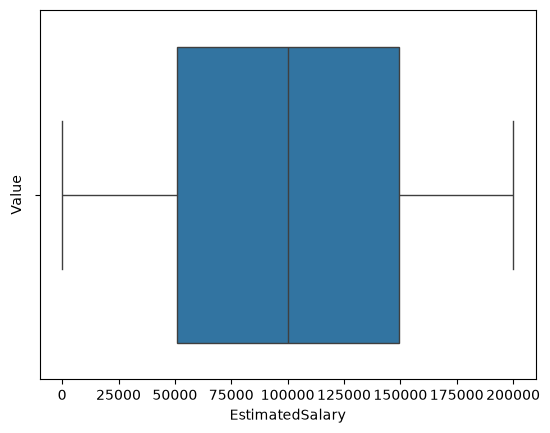

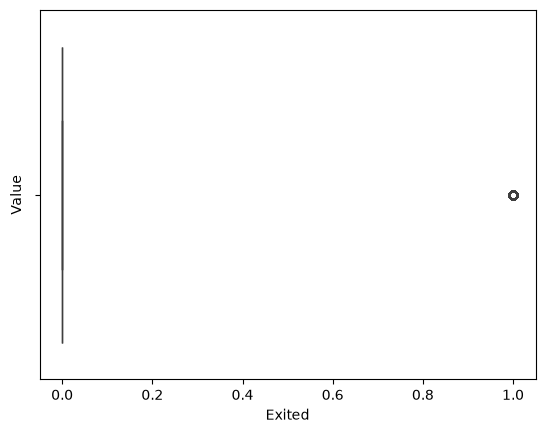

In [ ]:
for c in df.columns:
    sns.boxplot(x= df[c])
    plt.xlabel(c)
    plt.ylabel('Value')
    plt.show()

In [ ]:
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
cat_cols = ['Geography', 'Gender']
mapped_cat_cols = ['HasCrCard', 'IsActiveMember']

In [ ]:
df[num_cols].skew()

CreditScore       -0.071607
Age                1.011320
Balance           -0.141109
EstimatedSalary    0.002085
Tenure             0.010991
NumOfProducts      0.745568
dtype: float64

In [ ]:
from sklearn.preprocessing import PowerTransformer

transfomer = PowerTransformer(method='yeo-johnson', standardize= False)

df[['Age']] = transfomer.fit_transform(df[['Age']])

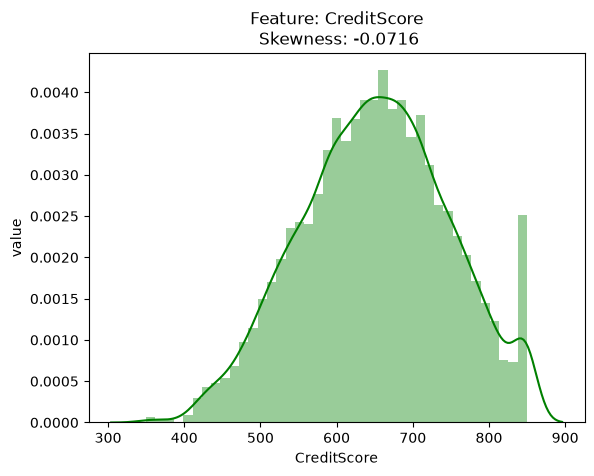

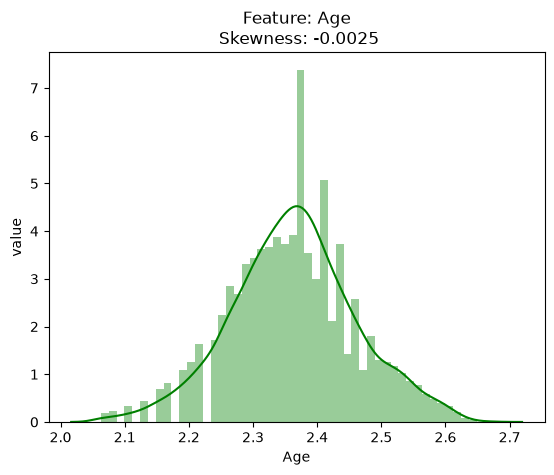

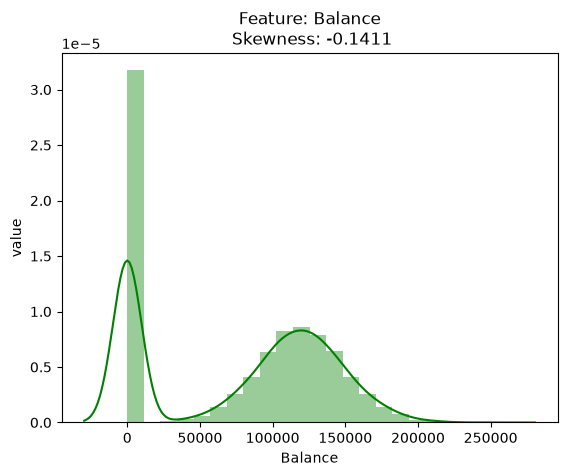

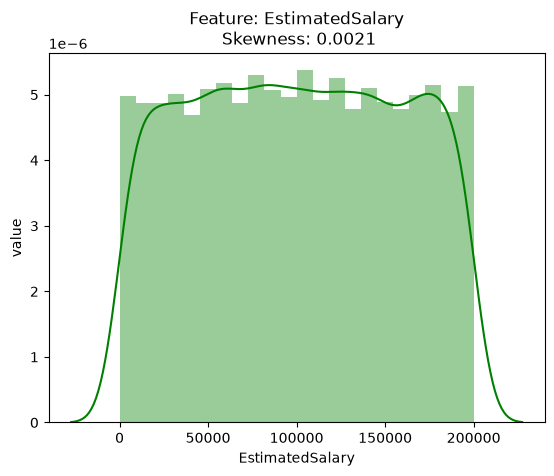

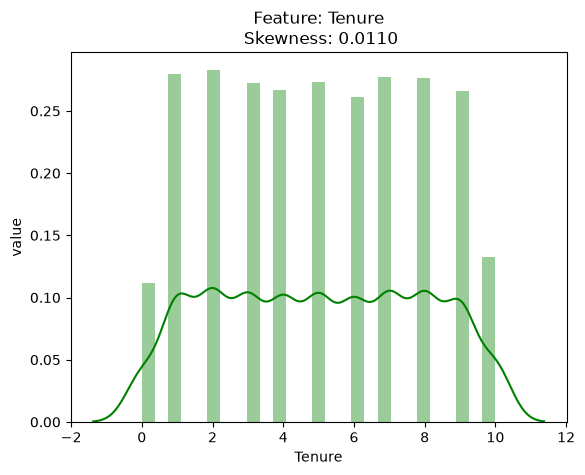

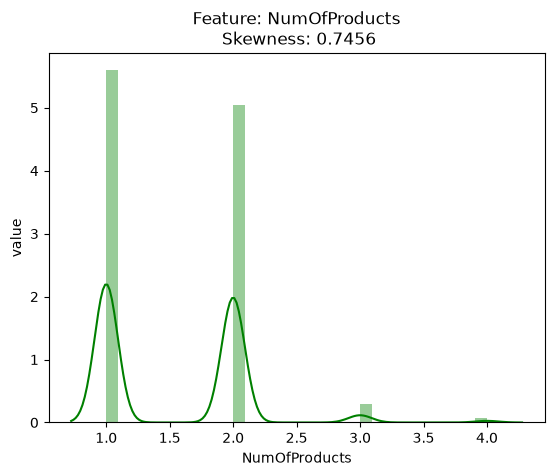

In [ ]:

for i in num_cols:
    sns.distplot(df[i],color='green')
    plt.title(f'Feature: {i}\n Skewness: {df[i].skew():.4f}')
    plt.xlabel(i)
    plt.ylabel('value')
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_copy.drop(columns=['Exited'])
y = df_copy['Exited']

X_train, X_test, y_train, y_test = train_test_split(X ,y ,test_size= 0.2 ,random_state=42, stratify=y)

In [ ]:
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()
X_test_copy = X_test.copy()
y_test_copy = y_test.copy()

In [ ]:
from collections import Counter
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC

fix_skew_cols = ['Age']
robust_scale_cols = ['CreditScore']
std_scale_cols = ['Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
cat_cols = ['Geography', 'Gender']
mapped_cat_cols = ['HasCrCard', 'IsActiveMember']


cat_cols_indices = [X_train.columns.get_loc(col) for col in cat_cols + mapped_cat_cols]
smote = SMOTENC(categorical_features= cat_cols_indices, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


for col in ['Tenure', 'NumOfProducts']:
    X_train_resampled[col] = X_train_resampled[col].round().astype(int)
    X_train_resampled[col] = X_train_resampled[col].clip(lower= X_train[col].min(), upper= X_train[col].max())

preprocessor = ColumnTransformer(transformers=[
    ('fix_skewness', PowerTransformer(method= 'yeo-johnson', standardize= True), fix_skew_cols),
    ('std_scaler', StandardScaler(), std_scale_cols),
    ('robust_scaler', RobustScaler(), robust_scale_cols),
    ('encoder', OneHotEncoder(sparse_output= False, handle_unknown='ignore', drop= 'if_binary', dtype= int), cat_cols)
],remainder= 'passthrough', verbose_feature_names_out= False)

#Data Without SMOTE
preprocessor.set_output(transform='pandas')
X_train_copy_final = preprocessor.fit_transform(X_train_copy)
X_test_copy_final = preprocessor.transform(X_test_copy)

preprocessor.set_output(transform='pandas')
X_train_transformed = preprocessor.fit_transform(X_train_resampled)
X_test_final = preprocessor.transform(X_test)
y_test_final = y_test
X_train_final = X_train_transformed
y_train_final = y_train_resampled

df_final = X_train_transformed.copy()
df_final['Exited'] = y_train_resampled.copy()

print('Shape: ')
display(df_final.shape)
print('Sample: ')
display(df_final.sample(10))

Shape: 


(12740, 13)

Sample: 


,Age,Balance,EstimatedSalary,Tenure,NumOfProducts,CreditScore,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember,Exited
9981,-1.407391,0.430432,-0.703942,-1.415455,-0.728400,0.507937,0,1,0,1,1,0,1
574,2.668447,-1.348935,-1.736601,0.053052,1.037502,0.015873,1,0,0,0,1,1,0
4974,-0.206774,-1.348935,-1.645099,0.787305,1.037502,-1.238095,0,0,1,1,1,1,0
1095,0.581145,-0.009871,-1.259960,-0.681202,-0.728400,1.373016,0,0,1,0,1,1,1
9639,-0.891222,1.538668,-0.087719,1.154432,-0.728400,-0.492063,0,1,0,0,1,0,1
10590,-0.101328,-1.348935,-0.751750,-0.681202,-0.728400,0.738095,1,0,0,0,1,1,1
10350,1.101945,0.242437,0.798751,-1.048328,-0.728400,-0.309524,0,1,0,1,1,0,1
10225,-1.015182,1.530956,0.216860,0.420179,-0.728400,-0.142857,0,0,1,1,1,0,1
10768,0.299743,0.466000,-0.233318,-0.681202,-0.728400,0.420635,0,1,0,1,1,0,1
6203,-1.545616,-1.348935,-1.640502,1.154432,1.037502,0.055556,0,0,1,0,0,0,0


After Balancing


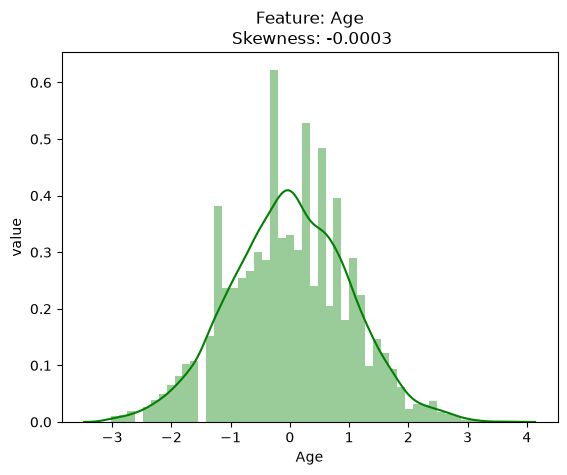

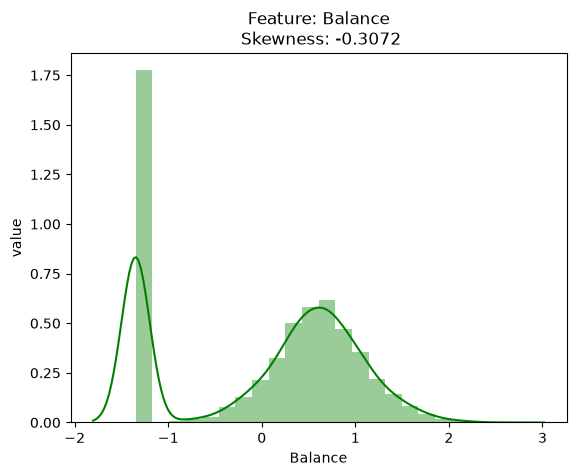

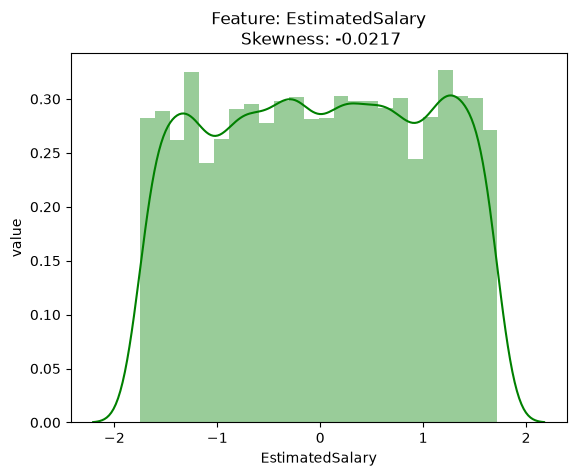

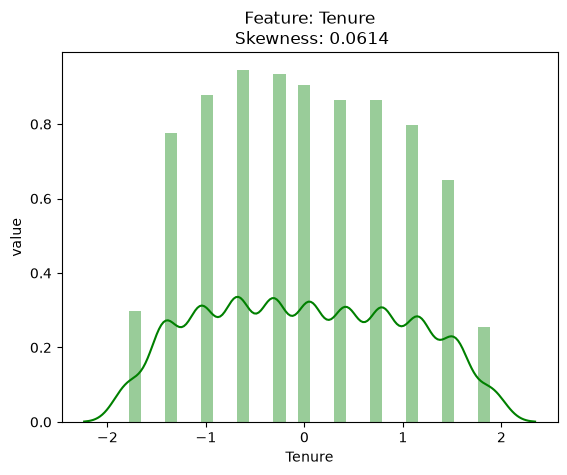

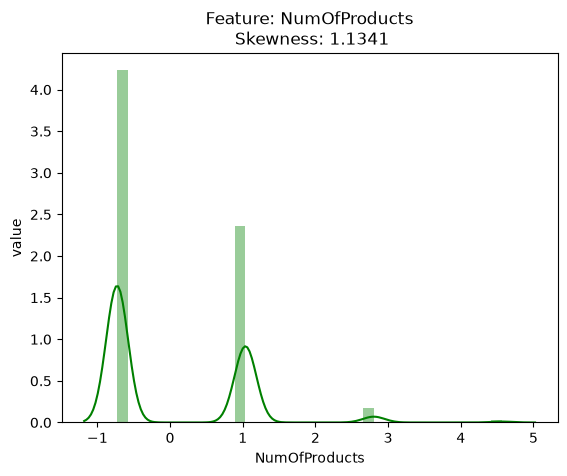

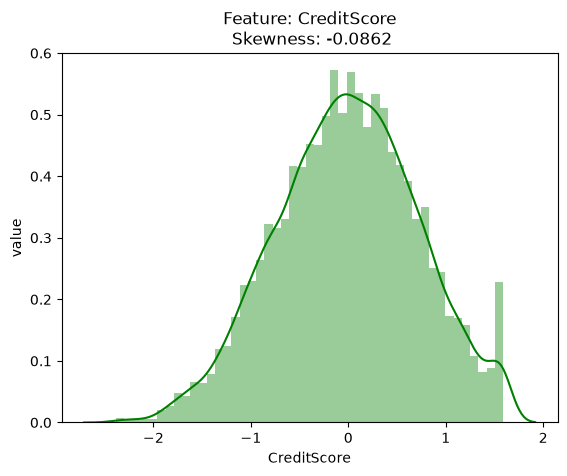

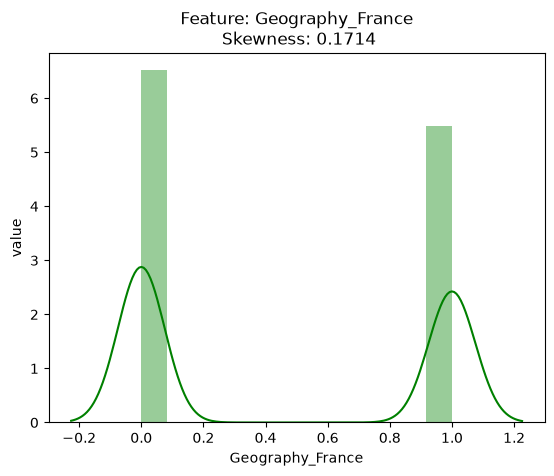

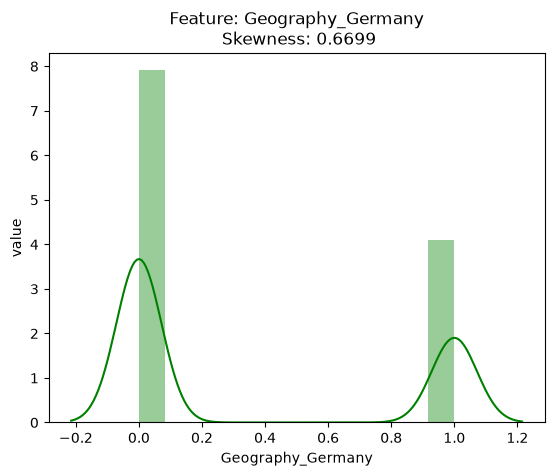

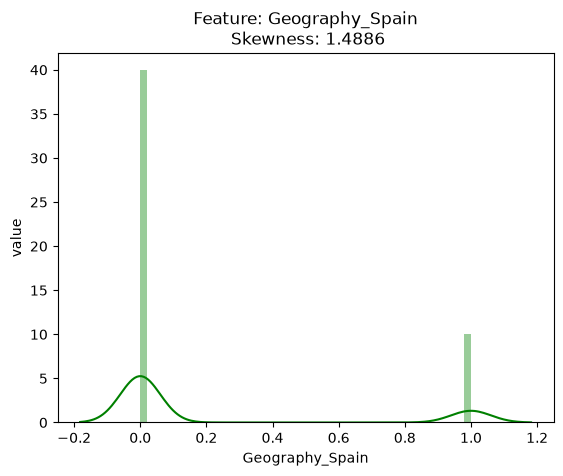

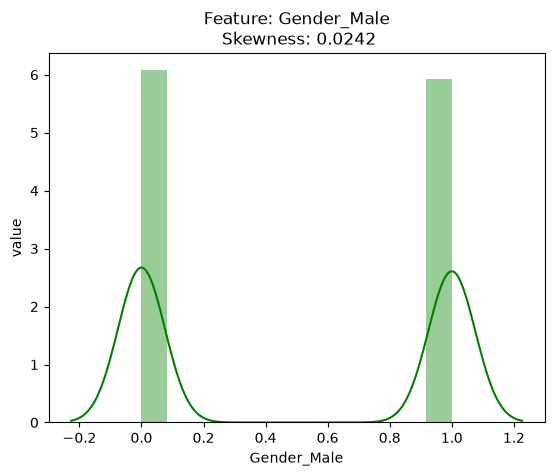

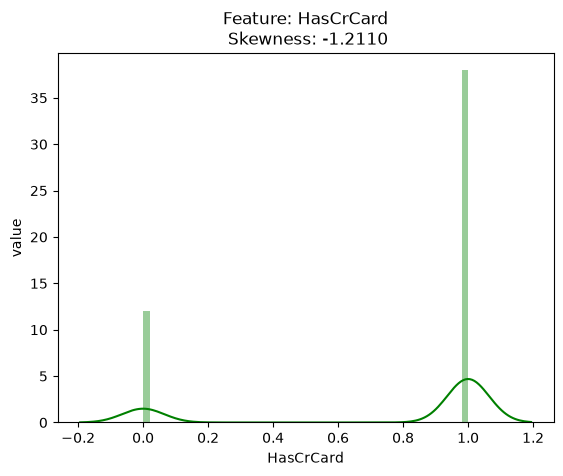

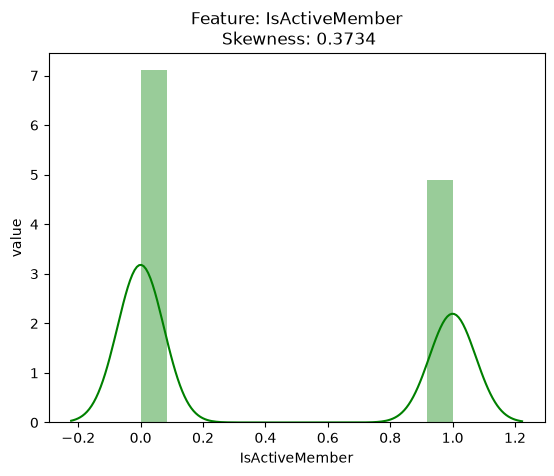

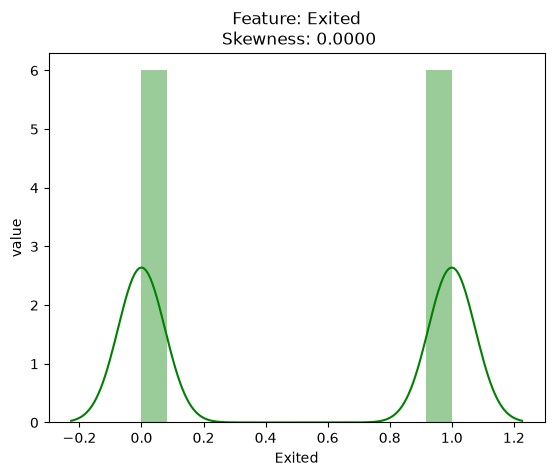

In [ ]:
print('After Balancing')

for i in df_final.columns:
    sns.distplot(df_final[i],color='green')
    plt.title(f'Feature: {i}\n Skewness: {df_final[i].skew():.4f}')
    plt.xlabel(i)
    plt.ylabel('value')
    plt.show()

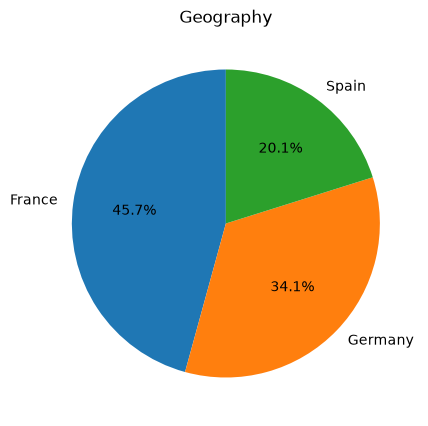

Geography
France     5826
Germany    4347
Spain      2567
Name: count, dtype: int64

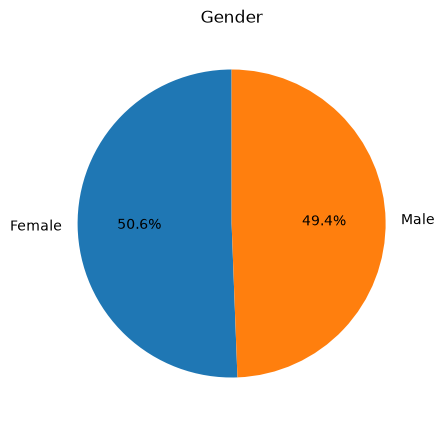

Gender
Female    6447
Male      6293
Name: count, dtype: int64

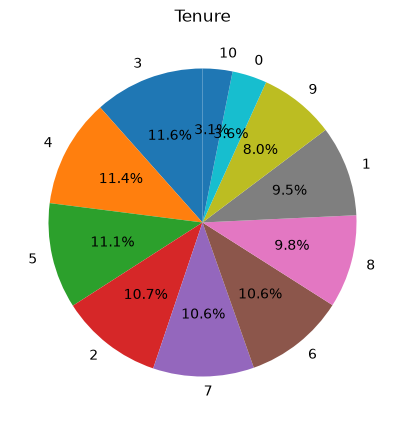

Tenure
3     1474
4     1455
5     1413
2     1367
7     1350
6     1348
8     1244
1     1212
9     1014
0      464
10     399
Name: count, dtype: int64

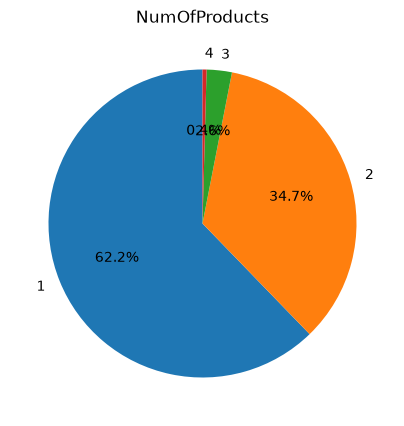

NumOfProducts
1    7930
2    4419
3     337
4      54
Name: count, dtype: int64

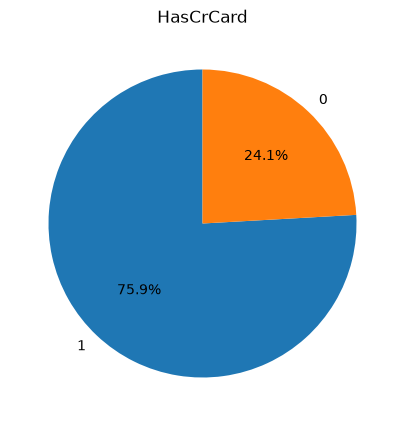

HasCrCard
1    9669
0    3071
Name: count, dtype: int64

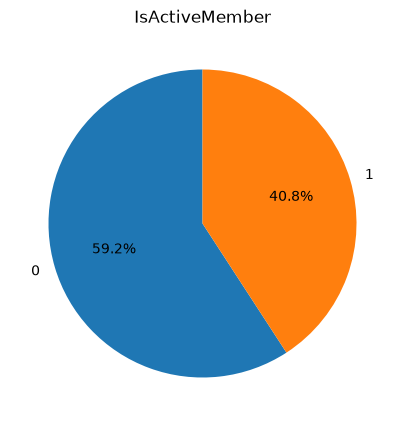

IsActiveMember
0    7539
1    5201
Name: count, dtype: int64

In [ ]:
for c in X_train_resampled.columns:
    if X_train_resampled[c].nunique() < 15:
        plt.figure(figsize=(5,5))
        X_train_resampled[c].value_counts().plot(kind='pie', autopct='%.1f%%', startangle=90)
        plt.ylabel('') 
        plt.title(c)
        plt.show()
        display(X_train_resampled[c].value_counts())

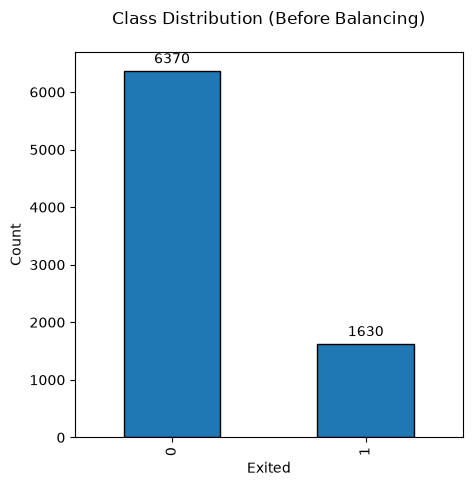

Exited
0    6370
1    1630
Name: count, dtype: int64

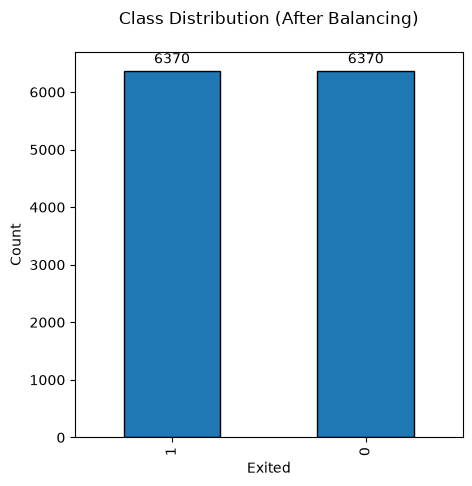

Exited
1    6370
0    6370
Name: count, dtype: int64

In [ ]:
li = {'Before Balancing':y_train, 'After Balancing':y_train_resampled}
for i, s in li.items():
    plt.figure(figsize=(5,5))
    ax = s.value_counts().plot(kind='bar', edgecolor='black')
    plt.ylabel('Count')
    ax.bar_label(ax.containers[0], padding=3)
    plt.title(f'Class Distribution ({i})\n')
    plt.show()
    display(s.value_counts())

In [ ]:
X_train_transformed.shape

(12740, 12)

In [ ]:
import keras
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [60]:
grab_best_weights = EarlyStopping(
    monitor='val_accuracy', 
    patience=50, 
    restore_best_weights=True
)

model= keras.Sequential()
model.add(Dense(64,activation='relu', input_shape= (X_train_final.shape[1],), kernel_initializer= 'he_normal'))
model.add(Dense(16,activation='relu', kernel_initializer= 'he_normal'))
model.add(Dense(1,activation='sigmoid', kernel_initializer= 'glorot_uniform'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model.fit(X_train_final,y_train_final,validation_data=(X_test_final,y_test_final),epochs=50, batch_size=10, callbacks= grab_best_weights)

Epoch 1/50


1274/1274 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7772 - loss: 0.4774 - val_accuracy: 0.8010 - val_loss: 0.4256
Epoch 2/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8024 - loss: 0.4296 - val_accuracy: 0.7990 - val_loss: 0.4194
Epoch 3/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8089 - loss: 0.4204 - val_accuracy: 0.8060 - val_loss: 0.4223
Epoch 4/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8130 - loss: 0.4122 - val_accuracy: 0.7765 - val_loss: 0.4637
Epoch 5/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8178 - loss: 0.4072 - val_accuracy: 0.7930 - val_loss: 0.4382
Epoch 6/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8172 - loss: 0.4023 - val_accuracy: 0.8005 - val_loss: 0.4316
Epoch 7/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8215 - loss: 0.3990 - val_accuracy: 0.7800 - val_loss: 0.4477
Epoch 8/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8229 - loss: 0.3955 - val_accurac

 1/63 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9062 - loss: 0.2811

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.4126

Final Finalized Model Accuracy: 0.8250
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


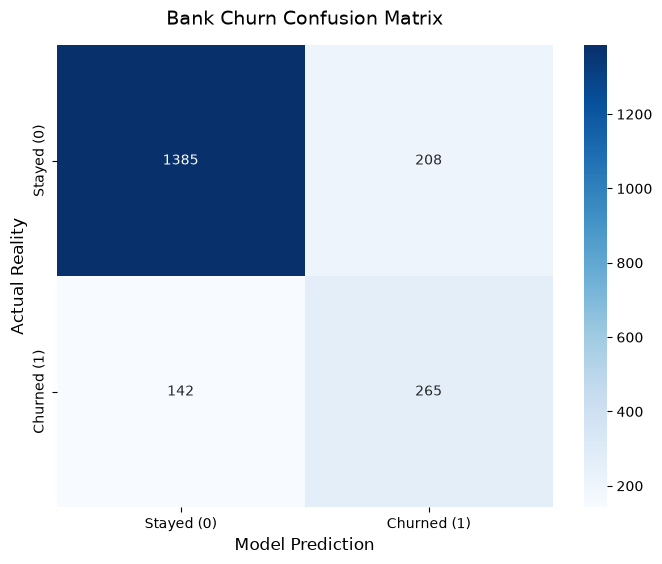

In [ ]:
loss, accuracy = model.evaluate(X_test_final, y_test_final)
print(f"\nFinal Finalized Model Accuracy: {accuracy:.4f}")

raw_probabilities = model.predict(X_test_final)

final_predictions = (raw_probabilities > 0.5).astype(int)

cm = confusion_matrix(y_test_final, final_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, 
    annot=True,        
    fmt='d',          
    cmap='Blues',     
    xticklabels=['Stayed (0)', 'Churned (1)'], 
    yticklabels=['Stayed (0)', 'Churned (1)']
)
plt.title('Bank Churn Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual Reality', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)

plt.show()

model.save(f'initial_model_{accuracy:.3f}.keras')

In [70]:
early_stop=EarlyStopping(monitor='val_accuracy',min_delta=0.00001,patience=20,verbose=1,mode='auto', restore_best_weights=True)

import os

os.makedirs('model_checkpoints', exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath='model_checkpoints/epoch_{epoch:02d}.keras', 
    monitor='val_accuracy',
    save_best_only=False,
    verbose=0
)

callbacks_list = [checkpoint, early_stop]

model_2= keras.Sequential()
model_2.add(Dense(64,activation='relu', input_shape= (X_train_final.shape[1],), kernel_initializer= 'he_normal'))
model_2.add(Dropout(0.1))
model_2.add(Dense(16,activation='relu', kernel_initializer= 'he_normal'))
model_2.add(Dropout(0.1))
model_2.add(Dense(1,activation='sigmoid', kernel_initializer= 'glorot_uniform'))
model_2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model_2.fit(X_train_final,y_train_final,validation_data=(X_test_final,y_test_final),epochs=50, batch_size=10,callbacks=callbacks_list)


Epoch 1/50


1274/1274 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7348 - loss: 0.5315 - val_accuracy: 0.7525 - val_loss: 0.5033
Epoch 2/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7884 - loss: 0.4576 - val_accuracy: 0.7935 - val_loss: 0.4484
Epoch 3/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7926 - loss: 0.4477 - val_accuracy: 0.7910 - val_loss: 0.4503
Epoch 4/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7990 - loss: 0.4410 - val_accuracy: 0.8080 - val_loss: 0.4262
Epoch 5/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8031 - loss: 0.4365 - val_accuracy: 0.8055 - val_loss: 0.4287
Epoch 6/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8040 - loss: 0.4331 - val_accuracy: 0.7890 - val_loss: 0.4518
Epoch 7/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8095 - loss: 0.4270 - val_accuracy: 0.7880 - val_loss: 0.4475
Epoch 8/50
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8082 - loss: 0.4247 - val_accurac

 1/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8750 - loss: 0.3133

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8105 - loss: 0.4192

Final Finalized Model Accuracy: 0.8250
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step


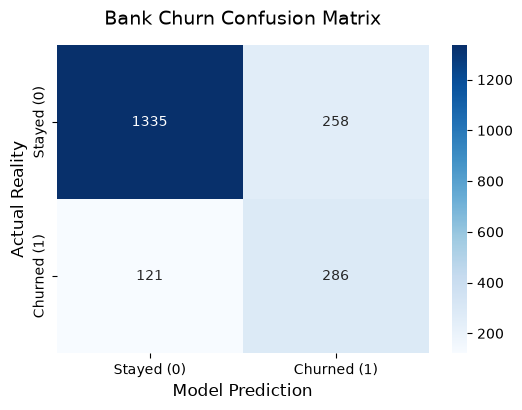

In [ ]:
loss_2, accuracy_2 = model_2.evaluate(X_test_final, y_test_final)
print(f"\nFinal Finalized Model Accuracy: {accuracy:.4f}")

probabilities = model_2.predict(X_test_final)

predictions = (probabilities > 0.5).astype(int)

cm = confusion_matrix(y_test_final, predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, 
    annot=True,        
    fmt='d',          
    cmap='Blues',     
    xticklabels=['Stayed (0)', 'Churned (1)'], 
    yticklabels=['Stayed (0)', 'Churned (1)']
)
plt.title('Bank Churn Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual Reality', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)

plt.show()

model.save(f'initial+dropout_model_{accuracy_2:.3f}.keras')

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(hp):
    model = Sequential()
    
    
    for i in range(hp.Int('num_layers', min_value=1, max_value=3)):
        
        
        hp_units = hp.Int(f'units_{i}', min_value=16, max_value=64, step=16)
        
        
        hp_activation = hp.Choice(f'activation_{i}', values=['relu', 'tanh'])
        
        model.add(Dense(units=hp_units, activation=hp_activation))
        
        
        hp_dropout = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.4, step=0.1)
        model.add(Dropout(hp_dropout))
        
    
    model.add(Dense(1, activation='sigmoid'))
    
    
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
    
    model.compile(
        optimizer=hp_optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [ ]:
# Initialize the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  
    directory='churn_tuning',
    project_name='keras_tuner_results'
)

print("Starting the automated search...")


tuner.search(
    X_train_final, y_train_final,
    validation_data=(X_test_final, y_test_final),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Trial 10 Complete [00h 00m 31s]
val_accuracy: 0.8119999766349792

Best val_accuracy So Far: 0.8245000243186951
Total elapsed time: 05h 09m 34s


In [47]:
print("\n=== KerasTuner Scoreboard ===")
tuner.results_summary(num_trials=3)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== The Winning Architecture ===")
print(f"Optimal Layers: {best_hp.get('num_layers')}")
print(f"Optimal Optimizer: {best_hp.get('optimizer')}")

final_best_model = tuner.get_best_models(num_models=1)[0]

loss, final_accuracy = final_best_model.evaluate(X_test_final, y_test_final)
print(f"\nFinal Finalized Model Accuracy: {final_accuracy:.4f}")


=== KerasTuner Scoreboard ===
Results summary
Results in churn_tuning\keras_tuner_results
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
num_layers: 1
units_0: 48
activation_0: relu
dropout_0: 0.1
optimizer: rmsprop
units_1: 64
activation_1: tanh
dropout_1: 0.30000000000000004
units_2: 64
activation_2: tanh
dropout_2: 0.2
Score: 0.8245000243186951

Trial 02 summary
Hyperparameters:
num_layers: 1
units_0: 32
activation_0: relu
dropout_0: 0.30000000000000004
optimizer: adam
Score: 0.8130000233650208

Trial 03 summary
Hyperparameters:
num_layers: 3
units_0: 16
activation_0: relu
dropout_0: 0.30000000000000004
optimizer: rmsprop
units_1: 16
activation_1: relu
dropout_1: 0.1
units_2: 16
activation_2: relu
dropout_2: 0.1
Score: 0.8119999766349792

=== The Winning Architecture ===
Optimal Layers: 1
Optimal Optimizer: rmsprop
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8245 - loss: 0.3948

Final Finalized Model Accuracy: 0.824

In [52]:
raw_probabilities = final_best_model.predict(X_test_final)

print(raw_probabilities[5:11])

final_predictions = (raw_probabilities > 0.5).astype(int)

print(final_predictions[5:11])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step
[[0.3688947 ]
 [0.07012855]
 [0.6903482 ]
 [0.75993073]
 [0.18235385]
 [0.8619346 ]]
[[0]
 [0]
 [1]
 [1]
 [0]
 [1]]


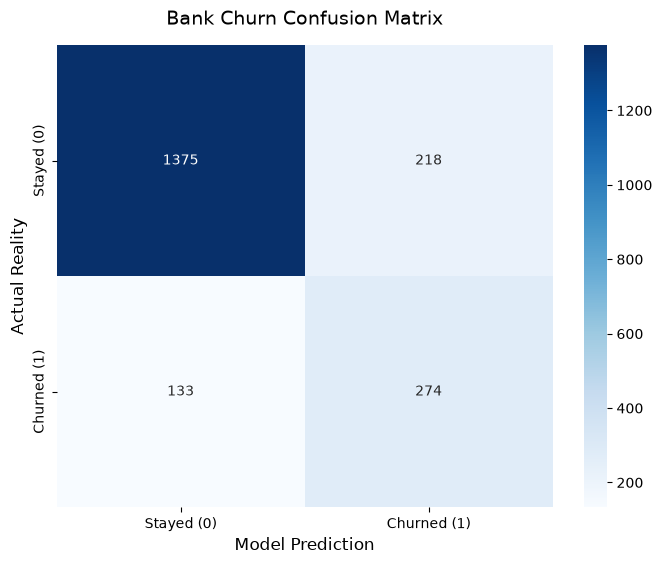

In [ ]:
from sklearn.metrics import confusion_matrix

raw_probabilities = final_best_model.predict(X_test_final)

final_predictions = (raw_probabilities > 0.5).astype(int)

cm = confusion_matrix(y_test_final, final_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, 
    annot=True,        
    fmt='d',          
    cmap='Blues',     
    xticklabels=['Stayed (0)', 'Churned (1)'], 
    yticklabels=['Stayed (0)', 'Churned (1)']
)
plt.title('Bank Churn Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual Reality', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)

plt.show()

In [65]:
final_best_model.save(f'tuner_best_model_{final_accuracy:.3f}.keras')